In [1]:
# suppress tensorflow logging, usually not useful unless you are having problems with tensorflow or accessing gpu
import os
#os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' 

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

# notebook wide settings for plotting visualizations
plt.rcParams['figure.figsize'] = (10, 8) # set default figure size, 10in by 8in

In [2]:
plt.rcParams['figure.figsize'] = (10, 8) # set default figure size, 10in by 8in

# Chapter 3: Introduction to Keras and TensorFlow

Supporting materials for:

Chollet (2021). *Deep Learning with Python*. 2nd ed. Manning Publications Co.
[Amazon](https://www.amazon.com/Learning-Python-Second-Fran%C3%A7ois-Chollet/dp/1617296864/ref=sr_1_1?crid=32NFM2SBCJVQQ)


We recreate the inputs from section 03.5 to use in the following example.

In [3]:
# generate two classes of random points in a 2D plane, each sample has 2 features (the covariance matrix ends up controlling this
num_samples_per_class = 1000

# first class of points, the negative samples for a binary classifier
negative_samples = np.random.multivariate_normal(
    mean=[0, 3],
    cov=[[1, 0.5],[0.5, 1]],
    size=num_samples_per_class)

# generate other class of positive samples, with slightly different mean and covariance
positive_samples = np.random.multivariate_normal(
    mean=[3, 0],
    cov=[[1, 0.5],[0.5, 1]],
    size=num_samples_per_class)

# classes are shaped (1000, 2), e.g. 1000 samples, each with 2 features
print(negative_samples.shape)
print(positive_samples.shape)

(1000, 2)
(1000, 2)


In [4]:
# stack the samples into a single array of training inputs of shape (2000, 2)
inputs = np.vstack((negative_samples, positive_samples)).astype(np.float32)
print(inputs.shape)

(2000, 2)


In [5]:
# generate target labels, 0's for the negative class and 1's for the positive class
targets = np.vstack((np.zeros((num_samples_per_class, 1), dtype="float32"),
                     np.ones((num_samples_per_class, 1), dtype="float32")))

print(targets.shape)

(2000, 1)


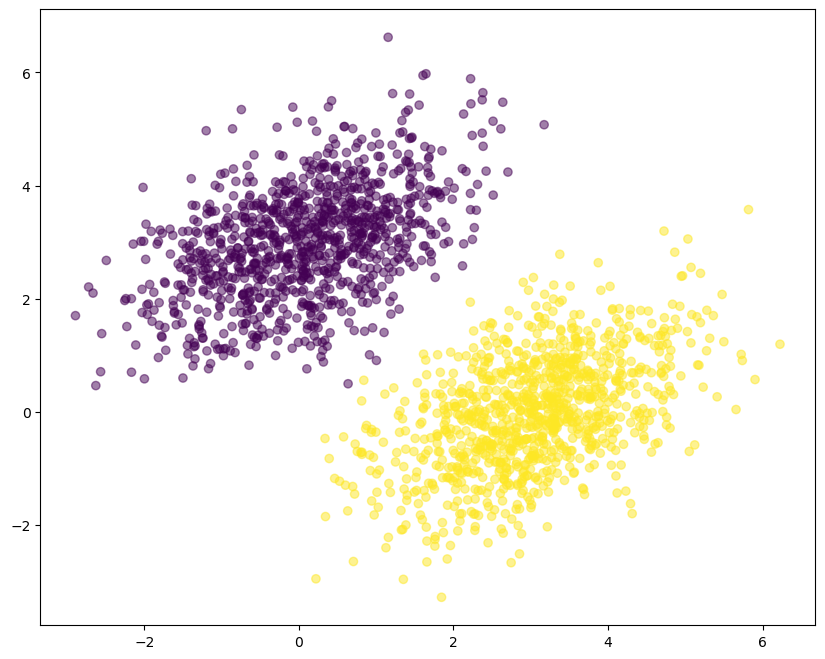

In [6]:
# visualize the two classes, color points based on the target labels
plt.scatter(inputs[:, 0], inputs[:, 1], c=targets[:, 0], alpha=0.5);

# 3.6 Anatomy of a neural network: Understanding core Keras APIs

The Keras API is a high-level interface for creating and training neural network and deep neural network models.  It uses the 
same mechansims we just used above of TensorFlow variables and gradient calculations behind the scenes.  But for the most part you
don't have to worry about the details of representing layer model parameters, calculating gradients, performing batch training, etc.

## 3.6.1 Layers: The building blocks of deep learning

The fundamental data structure of a neural network is the *layer*.  A typical layer acts like a single set of weight and bias
terms as we just worked with for a simple linear classification model.

A layer is a data processing module that takes as input one or more tensors, and that outputs one or more tensors.  Some layers
are stateless, but more frequently layers have a state: the layer's *weights* (and biases, together these are the trainable
parameters of the model).  These are represented as tensors that are trained using stochastic gradient descent.  This training
causes the layer (and model as a whole) to learn a function to transform the inputs into the desired outputs.

We will learn about different types of layers with different properties.  The simplest is a *densely connected* layer, also
called a *fully connected* or *dense* layer (the `Dense` class in Keras).  

You can think of layers as the LEGO bricks of deep learning.  Building deep learning models in Keras is done by
clipping together compatible layers to form useful data-transformation pipelines.


### The base layer class in Keras
Keras is an object-oriented design.  It has a `Layer` abstract base class, from which all specialized layers
are derived from.

We can build a layer ourself by extending the Keras API (though of course Keras already defines a `Dense` layer for us to use.

In [7]:
class SimpleDense(keras.layers.Layer):
    """All Keras layers inherit from the base Layer class
    """
    
    def __init__(self, units, activation=None):
        """Constructor, call superclass constructor first.
        units are the number of (hidden) units for this layer, which
        will also define the number of outputs of this layer
        activation is the activation (or output) function for
        this layer, if any (e.g. relu or sigmoid).
        """
        super().__init__()
        self.units = units
        self.activation = activation
        
    def build(self, input_shape):
        """build method when building a model.  The build method is defined in the
        Layer base class api, and is called on a Layer when the model compile() function
        is invoked.  Creation of weight and bias tensors takes place here.
        """
        input_dim = input_shape[-1]
        # add_weight is a shortcut method for creating weights.  Can also create standalone
        # TensorFlow variables, e.g. tf.Variable() as we did before.
        self.W = self.add_weight(shape=(input_dim, self.units),
                                 initializer="random_normal")
        self.b = self.add_weight(shape=(self.units,),
                                 initializer="zeros")
        
    def call(self, inputs):
        """Call method performs forward pass computation of this layer.
        """
        y = tf.matmul(inputs, self.W) + self.b
        if self.activation is not None:
            y = self.activation(y)
        return y

Once instantiated, a layer can be used just like a function, taking as input a TensorFlow tensor:

In [9]:
# instantiate our layer, 32 outputs using relu activation function
my_dense = SimpleDense(units=32, activation=tf.nn.relu)

# create some test inputs, shape (10,784) means there are two samples, with 784 input features into
# this layer
input_tensor = tf.ones(shape=(10,784))

# call the layer on the inputs, just like a function.  Note that the call() function is being
# invoked here to perform a forward pass.
output_tensor = my_dense(input_tensor)

# since there were 2 samples in the input, and since there are 32 (output) units in this layer, the
# result from the forward pass is a (2,32) shaped output tensor, 32 outputs for each of the 2 sample inputs.
print(output_tensor.shape)

(10, 32)


### Automatic shape inference: Building layers on the fly

An astute observer will see that we didn't specify the input_dim in the build function above, nor did we call
or invoke build anywhere.  Also if you know Python, it is actuall the `__call__()` method that is implicitly
called when you invoke a class instance as we did when we performed `my_dense(input_tensor)`.  So how were
the `build()` and `call()` functions used?

You can only "clip" together layers that are compatible.  This mainly means that each layer accepts inputs that it
expectss to be of a certain shape, and it returns output tensors of a(nother) certain shape.

For example

```python
from tensorflow.keras import layers
layer = layers.Dense(32, activation="relu")
```

will have the 0th dimension be the same as the number of samples of input, and the first dimension of the output will be 32.  It can only
be connected to a downstream layer that expects 32-dimensional vectors as its input.

Most of the time, Keras infers and handles size compatibility for you.  You don't have to do a lot of explicit stating of tensor shapes
and sizes.

For instance.

In [10]:
from tensorflow.keras import models
from tensorflow.keras import layers

model = models.Sequential([
    layers.Dense(32, activation="relu"),
    layers.Dense(32)
])

The layers didn't receive information about the shape of their inputs, instead they automatically infer their input
shape as being the shape of the first inputs that they see.

In the `SimpleDense` example layer we don't create the weights in the constructor.  Instead they are created in
a dedicated state-creation method, `build()`, which is called 1 time and receives as an argument the first input shape seen by
the layer.

The `build()` layer is called automatically the first time the layer is called.  Likewise, the `__call__()` method of the
base class calls the derived class `call()` method to perform the forward pass calculation.  This simplifies model
creation, and allows for more complex layer use cases.


## 3.6.2 From layers to models

A deep learning model is a graph of layers.

Can create model graphs using the `Model` class.

`Sequential` models are the simplest type of graph, stacks of layers where each layer gets input from the previous and sends output
to the next layer (except of course the first and last layers respectively).

But we can have more complex model graphs, including models with two or more branches of processing, more than a single input layer, to 
allow for two different but related inputs, residual connections.

The topology of a model defines a *hypothesis space*.

You make assumptions about your data.  These define what can be learned.  The hypothesis space of your model is extremely
important.  It encodes these assumptions being made about the problem. Thus picking or designing the right network architecutre is
difficult, and more art than science.  Though we will review some best practices on some common architectures that work well for
certain classes of problems.


## 3.6.3 The "compile" step: Configuring the learning process

Once you have settled on the model architecture, you still have 3 more things to specify

1. **Loss function (objective function, fitness function)** - The quantity that will be minimized during traing.  It represents
   a measure of success for the task.
2. **Optimizer** - Determines how network is updated based on the loss.  Usually stochastic gradient descent (SGD)
   modified in various ways to increase the search/optimization performance.
3. **Metrics** - The measures of success you want to monitor during training and validation, such as classification
   accuracy.  Training does not (and can not) optimize directly for these metrics.  But need loss functions that will
   translate to improving the desired metrics (not always easy or straight forward).
   
Once these are chosen, you `compile()` the model.  This is were you specify these 3 parts of the training.  Then you will call
`fit()` to perform actual batch training, fitting the model parameters to the desired outputs.

The `compile()` method configures the training process.  

In [11]:
# define a linear classifier
model = keras.Sequential([keras.layers.Dense(1)])

# specify an optimizer, there are many to choose from
# specify a loss function
# specify a list of metrics, can ask for reports on more than 1 metric
model.compile(optimizer="rmsprop",
              loss="mean_squared_error",
              metrics=["accuracy"])

## 3.6.4 Picking a loss function

Choosing the right loss function for your problem is extremely important.  If the objective doesn't correlate well with the
desired success for the task, you network will end up doing things you don't want.

## 3.6.5 Understanding the `fit()` method

After `compile()` we are ready to `fit()`.  The `fit()` method is the training loop.

We need the following arguments for training

- The **data** (inputs and targets) to train on.
- The number of **epochs** of training to perform.  (can specify other types of stopping conditions).
- The batch size to use within each epoch of mini-batch gradient descent.  This is the number of
  training examples considered to compute the gradients for one weight update.

In [12]:
history = model.fit(
    inputs,
    targets,
    epochs=5,
    batch_size=128
)


Epoch 1/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9981 - loss: 9.3043
Epoch 2/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9961 - loss: 8.9524
Epoch 3/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9958 - loss: 8.5135
Epoch 4/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9958 - loss: 8.1765
Epoch 5/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9981 - loss: 8.0635


The call to `fit()` returns a `History` object.  This object contains a `history` field which is a dictionary that gives 
a history of the metrics and loss over the training epochs.

In [13]:
history.history

{'accuracy': [0.996999979019165,
  0.996999979019165,
  0.996999979019165,
  0.996999979019165,
  0.996999979019165],
 'loss': [9.186566352844238,
  8.828614234924316,
  8.525118827819824,
  8.233819961547852,
  7.949308395385742]}

## 3.6.6 Monitoring loss and metrics on validation data

The goal of machine learning is to obtain models that perform well in general, on data that it has not seen before (generalization).

It's standard practice to reserve a subset of the training data as **validation data**.  You won't be training the model on this
validation data, but you will use it to compute the loss and metrics value on data unseen by the model.

You do this using the `validation_data` argument in `fit()`.

In [14]:
model = keras.Sequential([keras.layers.Dense(1)])
model.compile(optimizer=keras.optimizers.RMSprop(learning_rate=0.1),
              loss=keras.losses.MeanSquaredError(),
              metrics=[keras.metrics.BinaryAccuracy()])


# need to avoid having samples from only 1 class in validation data, shuffling the data before
# splitting is one way to do this.
indices_permutation = np.random.permutation(len(inputs))
shuffled_inputs = inputs[indices_permutation]
shuffled_targets = targets[indices_permutation]

# there are more sophisticated ways to perform train/validation/test splits
# here do it by hand, reserve 30% of the training data for validation
num_validation_samples = int(0.3 * len(inputs))
val_inputs = shuffled_inputs[:num_validation_samples]
val_targets = shuffled_targets[:num_validation_samples]
training_inputs = shuffled_inputs[num_validation_samples:]
training_targets = shuffled_targets[num_validation_samples:]

# now we fit again, giving the validation data separately and use donly to monitor
# the validation loss and metrics.
model.fit(
    training_inputs,
    training_targets,
    epochs=5,
    batch_size=16,
    validation_data=(val_inputs, val_targets)
)


Epoch 1/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - binary_accuracy: 0.6546 - loss: 1.8739 - val_binary_accuracy: 0.9783 - val_loss: 0.0481
Epoch 2/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - binary_accuracy: 0.9495 - loss: 0.0866 - val_binary_accuracy: 0.9967 - val_loss: 0.0500
Epoch 3/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - binary_accuracy: 0.9512 - loss: 0.0770 - val_binary_accuracy: 0.9700 - val_loss: 0.0594
Epoch 4/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - binary_accuracy: 0.9651 - loss: 0.0777 - val_binary_accuracy: 0.9950 - val_loss: 0.0421
Epoch 5/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - binary_accuracy: 0.9641 - loss: 0.0643 - val_binary_accuracy: 0.9967 - val_loss: 0.0385


Notice loss and accuracy are reported both for the training data and for the validation data.

Can use evaluate on a trained model, to for example calculate validation loss and metrics explicitly.

In [15]:
loss_and_metrics = model.evaluate(val_inputs, val_targets, batch_size=128)
print(loss_and_metrics)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - binary_accuracy: 0.9935 - loss: 0.0426
[0.03848398104310036, 0.996666669845581]


## 3.6.7 Inference: Using a model after training

Once trained, you will want to make some predictions.  This is called **inference**.  Can just call the model directly.
Or can use predict function to make predictions in batches.

In [16]:
predictions = model.predict(val_inputs, batch_size=128)
print(predictions[:10])

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
[[-0.17322099]
 [-0.22864455]
 [ 0.97843325]
 [-0.31413072]
 [ 1.1509374 ]
 [ 1.3040059 ]
 [ 0.03687212]
 [ 0.958151  ]
 [-0.12415189]
 [ 0.03957331]]
